In [19]:
import pandas as pd
import numpy as np
import time

In [6]:
df = pd.read_csv('/content/drive/MyDrive/Deep Learning/Social_Network_Ads.csv', usecols=['Age', 'EstimatedSalary', 'Purchased'])

In [7]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [8]:
x = df.iloc[:, :2]
y = df.iloc[:, -1]

In [11]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x_sc = sc.fit_transform(x)

In [53]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_sc, y, test_size = 0.2, random_state=2)

In [21]:
x_train.shape

(320, 2)

In [15]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [62]:
model = Sequential()

model.add(Dense(10, activation='relu',input_dim=2))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [63]:
model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [64]:
model.compile(loss='binary_crossentropy', metrics=['accuracy'])
start = time.time()
model.fit(x_train, y_train, epochs=10, batch_size=320)
print(time.time() - start)

# Here if the batch size = n i.e. no.of.rows in your data then you are doing batch gradient descent
# In BGD no.of.updates = no.of.epochs

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step - accuracy: 0.6187 - loss: 0.6439
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6250 - loss: 0.6364
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6344 - loss: 0.6311
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6406 - loss: 0.6268
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6500 - loss: 0.6230
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6562 - loss: 0.6195
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6562 - loss: 0.6164
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6656 - loss: 0.6134
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6719 - loss: 0.6106
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6812 - loss: 0.6079
1.1750712394714355


In [65]:
model = Sequential()

model.add(Dense(10, activation='relu',input_dim=2))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()
model.compile(loss='binary_crossentropy', metrics=['accuracy'])
start = time.time()
model.fit(x_train, y_train, epochs=10, batch_size=1)
print(time.time() - start)

# Here if the batch size = 1  then you are doing Stochastic gradient descent
# In SGD no.of.updates = no.of.rows * epochs

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_51 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6519 - loss: 0.6321
Epoch 2/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6756 - loss: 0.5012
Epoch 3/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7994 - loss: 0.3728
Epoch 4/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8590 - loss: 0.3513
Epoch 5/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9045 - loss: 0.2727
Epoch 6/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8817 - loss: 0.2690
Epoch 7/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9030 - loss: 0.2337
Epoch 8/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8994 - loss: 0.2605
Epoch 9/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8951 - loss: 0.2866
Epoch 10/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9345 - loss: 0.1980
8.491011619567871


In [80]:
model = Sequential()

model.add(Dense(10, activation='relu',input_dim=2))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x_sc, y, epochs=200, batch_size=400, validation_split=0.2)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3187 - loss: 0.7412 - val_accuracy: 0.6125 - val_loss: 0.7280
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.4062 - loss: 0.7331 - val_accuracy: 0.6250 - val_loss: 0.7245
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.4594 - loss: 0.7271 - val_accuracy: 0.6500 - val_loss: 0.7215
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.5250 - loss: 0.7220 - val_accuracy: 0.6500 - val_loss: 0.7189
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.5813 - loss: 0.7174 - val_accuracy: 0.6750 - val_loss: 0.7165
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.6281 - loss: 0.7132 - val_accuracy: 0.6875 - val_loss: 0.7142
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.6719 - loss: 0.7093 - val_accuracy: 0.6875 - val_loss: 0.7120
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.7156 - loss: 0.7055 - val_accuracy: 0.6875 - val_

In [78]:
model = Sequential()

model.add(Dense(10, activation='relu',input_dim=2))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x_sc, y, epochs=200, batch_size=1, validation_split=0.2)

#Here we can see on the same number of epochs SGD converges faster to the solution

Epoch 1/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5085 - loss: 0.7453 - val_accuracy: 0.5250 - val_loss: 0.6637
Epoch 2/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7809 - loss: 0.4290 - val_accuracy: 0.6875 - val_loss: 0.5793
Epoch 3/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8559 - loss: 0.3316 - val_accuracy: 0.7375 - val_loss: 0.5107
Epoch 4/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8740 - loss: 0.2898 - val_accuracy: 0.7875 - val_loss: 0.4570
Epoch 5/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8912 - loss: 0.2473 - val_accuracy: 0.8000 - val_loss: 0.4239
Epoch 6/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8586 - loss: 0.2953 - val_accuracy: 0.8125 - val_loss: 0.4077
Epoch 7/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8726 - loss: 0.3113 - val_accuracy: 0.8500 - val_loss: 0.3836
Epoch 8/200
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8811 - loss: 0.2490 - val_accu

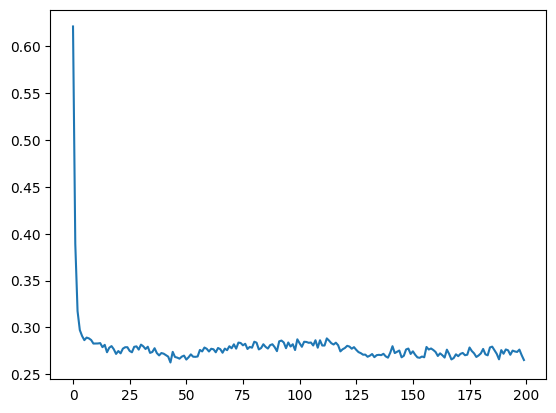

In [79]:
# SGD loss graph

import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

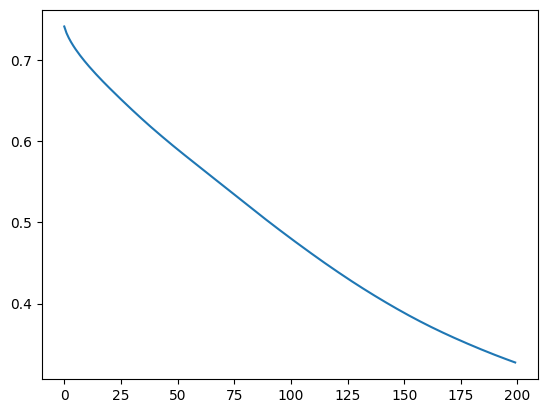

In [81]:
# BGD loss graph

import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.8031 - loss: 0.6407 - val_accuracy: 0.5125 - val_loss: 0.7331
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8213 - loss: 0.6250 - val_accuracy: 0.5250 - val_loss: 0.7270
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8289 - loss: 0.6196 - val_accuracy: 0.5375 - val_loss: 0.7244
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8334 - loss: 0.6101 - val_accuracy: 0.5375 - val_loss: 0.7223
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8357 - loss: 0.6065 - val_accuracy: 0.5500 - val_loss: 0.7188
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8274 - loss: 0.6010 - val_accuracy: 0.5625 - val_loss: 0.7145
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8447 - loss: 0.5906 - val_accuracy: 0.5500 - val_loss: 0.7121
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8509 - loss: 0.5836 - val_accuracy: 0.5500 - val_loss:

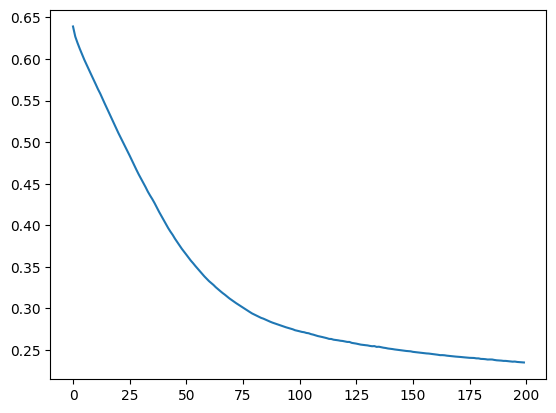

In [83]:
# MiniBGD loss graph
model = Sequential()

model.add(Dense(10, activation='relu',input_dim=2))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x_sc, y, epochs=200, batch_size=100, validation_split=0.2)

import matplotlib.pyplot as plt
plt.plot(history.history['loss'])